# 4.5 Beta 对冲与市场中性策略 (Beta Hedging)

> **为什么要对冲 Beta？**
> 即使你有一个胜率极高的选股模型（如 IC=0.05），如果你的组合整体 Beta > 1，
> 遇见熊市时你一样会大幅亏损——这是因为选股 Alpha 被市场风险压垮了。
>
> Beta 对冲的目标是：让组合免疫市场涨跌，**只赚取纯净的 Alpha 收益**。

## 学习目标
- 理解市场 Beta 对组合收益的影响
- 用 OLS 回归估计组合 Beta
- 通过做空指数期货实现 Beta 中性
- 验证对冲效果


真实 Beta: 1.30
OLS 估计 Beta: 1.3122
OLS 估计 Alpha（日）: 0.000423


C:\Users\DELL\.conda\envs\quant\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\DELL\.conda\envs\quant\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\DELL\.conda\envs\quant\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\DELL\.conda\envs\quant\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\DELL\.conda\envs\quant\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-653

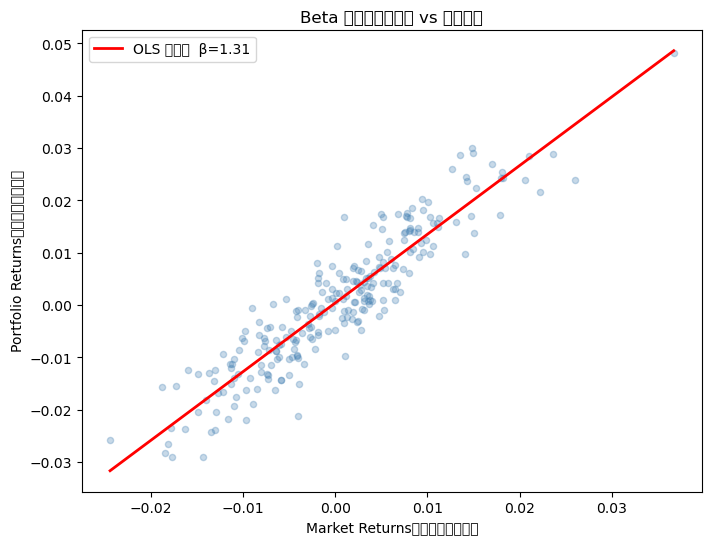

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(42)
n = 252  # 一年交易日

# 模拟市场收益率（年化8%，波动15%）
market_returns = np.random.normal(0.08/252, 0.15/np.sqrt(252), n)

# 模拟一个做多组合：Beta = 1.3, Alpha = 0.0003（正的超额日收益）
true_beta = 1.3
true_alpha_daily = 0.0003

portfolio_returns = (true_alpha_daily + true_beta * market_returns
                     + np.random.normal(0, 0.005, n))  # 特质噪音

# 用 OLS 估计组合 Beta
X = sm.add_constant(market_returns)
ols = sm.OLS(portfolio_returns, X).fit()
estimated_beta = ols.params[1]
estimated_alpha = ols.params[0]

print(f"真实 Beta: {true_beta:.2f}")
print(f"OLS 估计 Beta: {estimated_beta:.4f}")
print(f"OLS 估计 Alpha（日）: {estimated_alpha:.6f}")

# 可视化 Beta 回归散点图
plt.figure(figsize=(8, 6))
plt.scatter(market_returns, portfolio_returns, alpha=0.3, color='steelblue', s=20)
plt.plot(sorted(market_returns),
         [ols.params[0] + ols.params[1]*x for x in sorted(market_returns)],
         color='red', linewidth=2, label=f'OLS 回归线  β={estimated_beta:.2f}')
plt.xlabel('Market Returns（市场日收益率）')
plt.ylabel('Portfolio Returns（组合日收益率）')
plt.title('Beta 估计：组合收益 vs 市场收益')
plt.legend()
plt.show()


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. Beta 暴露的危险

假设你确信你的选股 Alpha 是真实的，但你的组合 Beta = 1.3。
在熊市下跌 20% 的年份，你的组合会因为 Beta 暴露损失约 **26%**，
而 Alpha 只能贡献约 **0.03% × 252 ≈ 7.5%**，最终组合还是下跌了约 **18.5%**。

**Beta 是 Alpha 最大的敌人。** 对冲 Beta 是让 Alpha 按原有量级释放的前提。


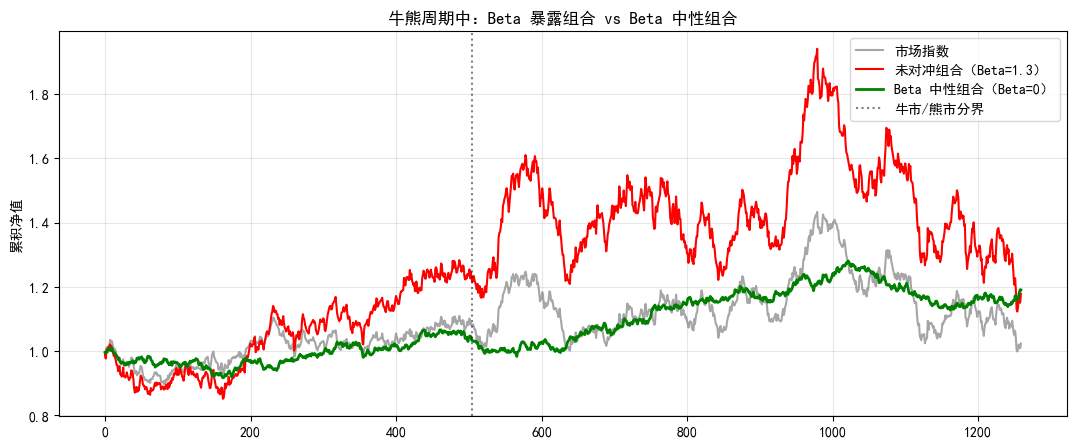

5年总收益:
  市场指数:        2.38%
  未对冲组合: 17.85%
  Beta中性组合:  19.09%


In [3]:
# 演示 Beta 暴露的危害
years = 5
daily_returns_market = np.random.normal(0.06/252, 0.18/np.sqrt(252), 252*years)

# 模拟牛熊周期（前2年牛，后3年轻微熊）
market_drift = np.concatenate([
    np.random.normal(0.12/252, 0.15/np.sqrt(252), 252*2),   # 牛市
    np.random.normal(-0.05/252, 0.20/np.sqrt(252), 252*3)   # 熊市
])

alpha_daily = 0.0003  # 每日 +0.03% 纯 Alpha
portfolio_unhedged = alpha_daily + true_beta * market_drift + np.random.normal(0, 0.005, 252*years)
portfolio_hedged   = alpha_daily + 0 * market_drift + np.random.normal(0, 0.005, 252*years)  # Beta=0

cum_market    = (1 + market_drift).cumprod()
cum_unhedged  = (1 + portfolio_unhedged).cumprod()
cum_hedged    = (1 + portfolio_hedged).cumprod()

plt.figure(figsize=(13, 5))
plt.plot(cum_market, color='gray', alpha=0.7, label='市场指数')
plt.plot(cum_unhedged, color='red', label=f'未对冲组合（Beta={true_beta}）')
plt.plot(cum_hedged, color='green', linewidth=2, label='Beta 中性组合（Beta=0）')
plt.axvline(252*2, color='black', linestyle=':', alpha=0.5, label='牛市/熊市分界')
plt.title('牛熊周期中：Beta 暴露组合 vs Beta 中性组合')
plt.ylabel('累积净值')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"5年总收益:")
print(f"  市场指数:        {cum_market[-1]-1:.2%}")
print(f"  未对冲组合: {cum_unhedged[-1]-1:.2%}")
print(f"  Beta中性组合:  {cum_hedged[-1]-1:.2%}")


## 2. 实施 Beta 对冲：做空股指期货

最常见的 Beta 对冲方式是做空股指期货（如沪深300指数期货 IF）：

$$\text{对冲手数} = \frac{\text{组合市值} \times \hat{\beta}}{\text{合约面值}}$$

通过调整做空手数，使得组合 + 期货空头的总 Beta ≈ 0。


In [4]:
# Beta 对冲实施计算
portfolio_value = 10_000_000  # 组合市值 1000万元
contract_size = 300_000       # 股指期货一手合约面值（假设指数3000点×乘数100）

# 需要做空的手数
hedge_lots = portfolio_value * estimated_beta / contract_size
print(f"组合市值: {portfolio_value:,.0f} 元")
print(f"估计组合 Beta: {estimated_beta:.4f}")
print(f"每手合约面值: {contract_size:,.0f} 元")
print(f"需要做空 {hedge_lots:.2f} 手期货合约（取整为 {int(hedge_lots)} 手）")

# 对冲后的残余 Beta
hedge_lots_int = int(hedge_lots)
hedge_notional = hedge_lots_int * contract_size
residual_beta = (portfolio_value * estimated_beta - hedge_notional) / portfolio_value
print(f"\n对冲后残余 Beta: {residual_beta:.4f} (目标: ~0)")


组合市值: 10,000,000 元
估计组合 Beta: 1.3122
每手合约面值: 300,000 元
需要做空 43.74 手期货合约（取整为 43 手）

对冲后残余 Beta: 0.0222 (目标: ~0)


## 🎯 练习

1. 对不同时间窗口（60日，120日，252日）分别估计 Beta，观察哪个窗口的 Beta 更稳定。
2. 使用滚动回归（`sm.OLS` 在滚动窗口内）计算时变 Beta，用卡尔曼滤波结果与其对比。
3. 模拟加入 3 只不同行业 Beta 的股票组成的组合，计算整体组合 Beta，然后分别计算对冲量。

---
**下一节** → `06_pairs_trading_strategy.ipynb`
